# Data Science Infrastructure - Spark Structured Streaming and Kafka

This iPython notebooks shows a Spark/Kafka application for a real-world scenario (Wikipedia) and was taken from here: https://towardsdatascience.com/enabling-streaming-data-with-spark-structured-streaming-and-kafka-93ce91e5b435


Apache Kafka is being largely adopted in modern architectures providing a more reliable and scalable way to capture and integrate real-time data between systems. It provides among other features a scalable and fault-tolerant distributed framework, APIs to publish /consume event streams and it allows you to control how long the event will be stored.

Important Kafka concepts:

* Broker: A Kafka cluster consists of one or more servers running Kafka. These servers are called brokers and the Zookeeper service manages them.
* Topic: Is a category/feed name to which records are stored and published. It is divided into partitions that are split across multiple brokers, allowing parallelization.
* Producers: Applications that push records into Kafka topics within the broker.
* Consumers: Applications that pull records off a Kafka topic.

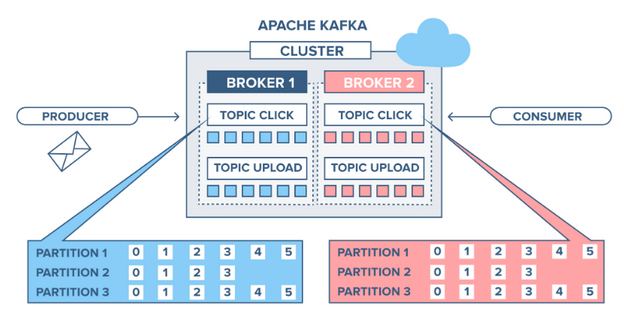

Apache Spark has an engine called Spark Structured Streaming to process streams in a fast, scalable, fault-tolerant process. It uses micro-batches to process data streams as a series of small-batch jobs with low latency.

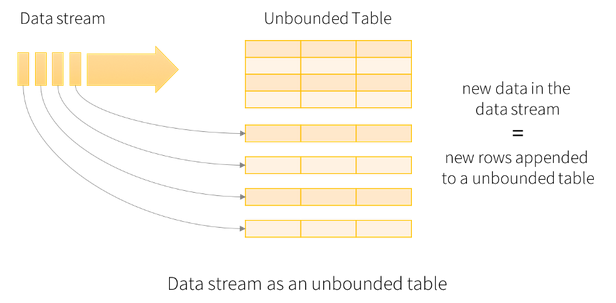

In this article, Kafka is used to store the streaming events produced by Wikipedia containing changes on wiki pages.

Spark Structured Streaming will be used to process and transform the event in a report of the top 10 users with more editions in a time window frame.

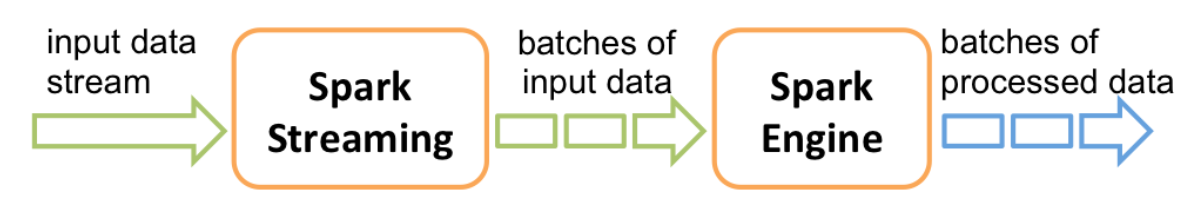

## Architecture

The following picture shows the high-level architecture used in this article:

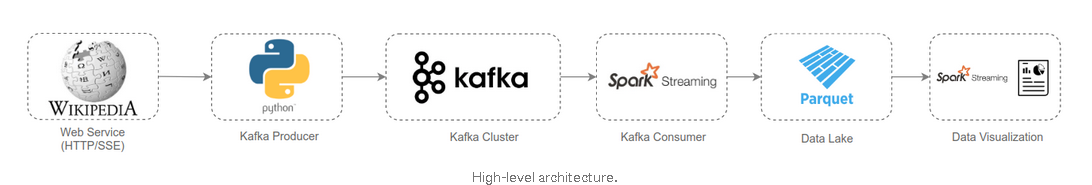

A Python application will consume streaming events from a Wikipedia web service and persist it into a Kafka topic. Then, a Spark Streaming application will read this Kafka topic, apply some transformations, and save the streaming event in Parquet format. Another Spark Streaming application will read the Parquet files to generate the report.

**Parquet is not beeing used in this Notebook !!**
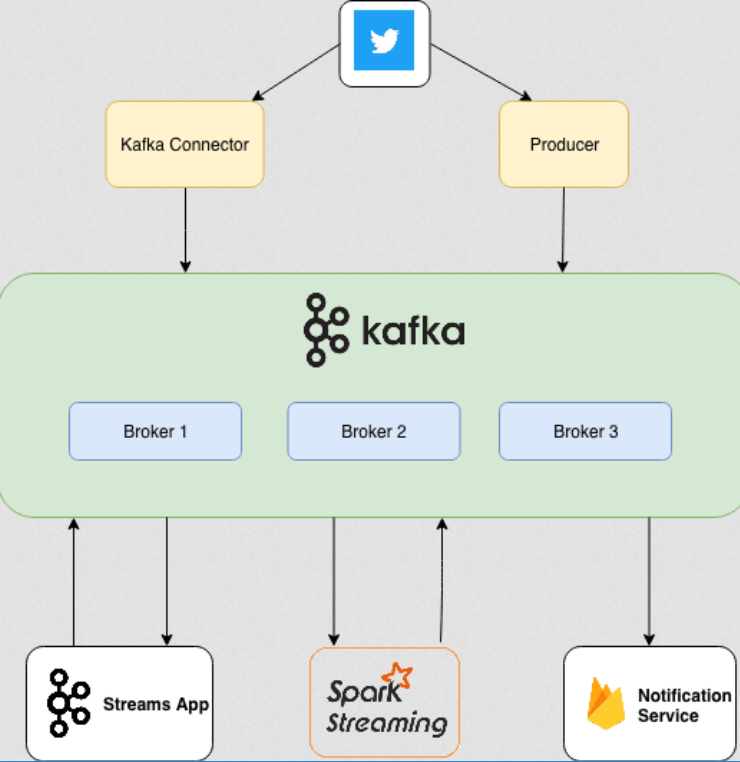

## Setting up the environment

Components of the environment:

**Zookeeper**: required by Kafka to keep track of cluster nodes, topics, partitions, etc.

**Kafka**: the Kafka cluster.

**Spark**: Jupyter service with Spark embedded to interactively run the spark application.

## Setup Kafka Producer

In [33]:
from kafka import KafkaProducer
import yfinance as yf
import json
import time

# Function to fetch stock data
def fetch_stock_data(ticker):
    stock = yf.Ticker(ticker)
    data = stock.history(period="1d", interval="1m")
    return data

# Kafka Producer
producer = KafkaProducer(
    bootstrap_servers='172.29.16.101:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

# List of stock tickers to stream
tickers = ["AAPL", "GOOGL", "MSFT"]

while True:
    for ticker in tickers:
        data = fetch_stock_data(ticker)
        for index, row in data.iterrows():
            message = {
                "ticker": ticker,
                "datetime": index.strftime("%Y-%m-%d %H:%M:%S"),
                "open": row['Open'],
                "high": row['High'],
                "low": row['Low'],
                "close": row['Close'],
                "volume": row['Volume']
            }
            producer.send('stock-prices', value=message)
            print(f"Sent data: {message}")
    time.sleep(60)  # Fetch data every minute
eep(60)  # Fetch data every minute


Sent data: {'ticker': 'AAPL', 'datetime': '2024-06-20 09:30:00', 'open': 213.92999267578125, 'high': 214.14999389648438, 'low': 213.4499969482422, 'close': 213.89999389648438, 'volume': 3550869.0}
Sent data: {'ticker': 'AAPL', 'datetime': '2024-06-20 09:31:00', 'open': 213.90499877929688, 'high': 214.24000549316406, 'low': 213.22000122070312, 'close': 213.2675018310547, 'volume': 452151.0}
Sent data: {'ticker': 'AAPL', 'datetime': '2024-06-20 09:32:00', 'open': 213.27000427246094, 'high': 213.28599548339844, 'low': 212.66000366210938, 'close': 212.74000549316406, 'volume': 514019.0}
Sent data: {'ticker': 'AAPL', 'datetime': '2024-06-20 09:33:00', 'open': 212.7899932861328, 'high': 212.86000061035156, 'low': 212.27000427246094, 'close': 212.3699951171875, 'volume': 519647.0}
Sent data: {'ticker': 'AAPL', 'datetime': '2024-06-20 09:34:00', 'open': 212.35499572753906, 'high': 212.6999969482422, 'low': 212.3000946044922, 'close': 212.63999938964844, 'volume': 358387.0}
Sent data: {'ticker'

KeyboardInterrupt: 

## Spark Streaming event consumer

The Spark notebook that consumes the events is composed of the following steps:

* The Kafka topic is read by the Stream Dataframe called df.
* The key and value received by the Kafka topic are converted to String then a schema is defined for value, generating the df_wiki.
* Some transformations like converting to a tabular format, column renaming, and column conversion are made over df_wiki, generating the df_wiki_formatted.
* The queryStream persists the df_wiki_formatted dataframe as parquet files partitioned by change_timestamp_date and server_name.
* The queryStreamMem reads the parquet files as stream to output the number of rows every 5 seconds — just for debugging. Note that the memory output sink is not the recommended output to use in production.

**create new Spark instance**

In [63]:
from pyspark.sql import SparkSession

# Starte eine Spark-Session und verbinde mit dem Spark-Server
spark = (SparkSession
         .builder
         .appName('stock-prices-consumer')
         .master('spark://172.29.16.102:7077')
         .config("spark.executor.extraJavaOptions", "-Djava.security.egd=file:/dev/./urandom")
         .config("spark.driver.extraJavaOptions", "-Djava.security.egd=file:/dev/./urandom")
         .getOrCreate())
sc = spark.sparkContext

# Überprüfe, ob die Spark-Session läuft
print(spark)

PySparkRuntimeError: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.

**Create stream dataframe setting kafka server, topic and offset option**

In [68]:
#funktioniert nicht?
!pyspark --version

Der Befehl "pyspark" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


In [67]:
#funktioniert?
import pyspark
print(pyspark.__version__)

3.5.1


In [69]:
# Erstellen eines Datenstrom-DataFrames mit Kafka-Server, Thema und Offset-Optionen
df = (spark
      .readStream
      .format("kafka")
      .option("kafka.bootstrap.servers", "172.29.16.101:9092")
      .option("subscribe", "stock-prices")
      .option("startingOffsets", "earliest")
      .load())

# Überprüfe das Schema des DataFrames
df.printSchema()


NameError: name 'spark' is not defined

**convert some data and make it available as dataframe again**

In [44]:
display(df)

NameError: name 'df' is not defined

In [45]:
from pyspark.sql.types import StringType

# Convert binary to string key and value
df1 = (df
    .withColumn("key", df["key"].cast(StringType()))
    .withColumn("value", df["value"].cast(StringType())))

NameError: name 'df' is not defined

In [46]:
display(df1)

NameError: name 'df1' is not defined

**create a structure that is used as schema for the streamed data**

In [47]:
from pyspark.sql.functions import from_json
from pyspark.sql.types import StructType, StructField, StringType, FloatType, IntegerType

schema_stock = StructType(
    [StructField("ticker", StringType(), True),
     StructField("datetime", StringType(), True),
     StructField("open", FloatType(), True),
     StructField("high", FloatType(), True),
     StructField("low", FloatType(), True),
     StructField("close", FloatType(), True),
     StructField("volume", IntegerType(), True)]
)

df_stock = (df1
           .withColumn("value", from_json("value", schema_stock)))


NameError: name 'df1' is not defined

In [48]:
display(df_stock)

NameError: name 'df_stock' is not defined

**reformat some fields of of the data streaming in and changing the field names**

In [49]:
from pyspark.sql.functions import col, to_timestamp

df_stock_formatted = (df_stock.select(
    col("value.ticker").alias("ticker"),
    to_timestamp(col("value.datetime")).alias("datetime"),
    col("value.open").alias("open"),
    col("value.high").alias("high"),
    col("value.low").alias("low"),
    col("value.close").alias("close"),
    col("value.volume").alias("volume")
))


NameError: name 'df_stock' is not defined

**show the old and new data format of the streaming data**

In [50]:
print("previous data format:")
display(df_stock)
print();
print("new data format:")
display(df_stock_formatted)

previous data format:


NameError: name 'df_stock' is not defined

## Visualizing Streaming Data

The following steps compose the visualization notebook that shows the top 10 users with more page editions in near real-time:

* The df_count is generated by the count of changes (rows) by every 10 minutes time frame based on the event timestamp (change_timestamp column). Here it’s applied the window-based aggregation concept with windows of 10 minutes, sliding every 10 minutes. Another important feature here is the watermarking that doesn’t aggregate events arriving more than 10 minutes late considering the event timestamp.
* The queryStream object outputs the df_count to a table in memory called wiki_changes that can be accessed as a table in Spark SQL to extract the top 10 users with more page editions.
* The final output is printed as graph (using seaborn library) and table (converting the spark dataframe to Pandas dataframe). If the producer and consumer applications are running, this notebook will output an updated graph and table every 10 seconds.

**create a new dataframe that extracts only the data of a sliding window, groups and counts the results**

**check the resulting structure to see the difference**

In [51]:
from pyspark.sql.functions import window

df_aggregated = (
    df_stock_formatted
    .withWatermark("datetime", "1 minute")
    .groupBy(
        window(col("datetime"), "1 minute", "1 minute"),  # 1-minute window
        col("ticker")
    )
    .agg({"close": "avg"})
    .withColumnRenamed("avg(close)", "avg_close")
)

display(df_aggregated)

NameError: name 'df_stock_formatted' is not defined

**until this point streaming has not started yet - just dataframe manipulations took place that are worked off in lazy evaluation mode**

**the following lines actually start streaming (see ".start" at the end of the code)**

In [52]:
# Create query stream with memory sink
queryStream = (df_aggregated
 .writeStream
 .format("memory")
 .queryName("stock_prices")
 .outputMode("update")
 .start())

NameError: name 'df_aggregated' is not defined

In [53]:
# Check active streams
for s in spark.streams.active:
    print("ID:{} | NAME:{}".format(s.id, s.name))

NameError: name 'spark' is not defined

**the following code visualizes the streamed data in form of Pandas tables and a Seaborn plot**

In [54]:
from time import sleep
from IPython.display import clear_output
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

try:
    while True:
        clear_output(wait=True)
        df = spark.sql(
                """
                SELECT
                    window.start AS start,
                    window.end AS end,
                    ticker,
                    avg_close
                FROM
                    stock_prices
                WHERE
                    window.start = (SELECT MAX(window.start) FROM stock_prices)
                """
        ).toPandas()

        plt.figure(figsize=(12, 6))
        sns.lineplot(x="start", y="avg_close", hue="ticker", data=df)
        plt.title("Average Close Prices")
        plt.show()

        display(df)

        sleep(10)
except KeyboardInterrupt:
    print("process interrupted.")
    queryStream.stop()

NameError: name 'spark' is not defined

In [ ]:
# stop stream
queryStream.stop()
#sc.stop()

## Final thoughts

This article is considered to be a guide on how to set up an environment with Spark and Kafka, create a Python event producer, a Spark event consumer, how to ingest the events in a persistence layer, and how to consume these events to generate a report in near real-time.

Jupyter was chosen to create the Python and Spark applications just because it’s interactive and easier for people who are starting with Spark.

I don't recommend using the memory sink for streaming dataframes in production because it uses the driver’s memory.

Regarding data visualization, there are a lot of solutions that can be used and you should evaluate which of them better fits your necessity when planning a production application. I choose in this article the seaborn library because it generates the graph by code and it’s simple to use in this use case.

## Trying to fix errors:

In [61]:
import os

# Setze die JAVA_HOME Umgebungsvariable
os.environ['JAVA_HOME'] = 'C:\\Program Files\\Java\\jdk-11'

# Überprüfe, ob JAVA_HOME korrekt gesetzt ist
print(os.environ.get('JAVA_HOME'))

C:\Program Files\Java\jdk-11
